# Tokenizer Effective Rank: Linear vs. FFN

Compare the *raw tokenizer outputs* (before any encoder block) for the twin 100 Hz dev runs:

- `dev_100hz` — single linear projection per patch (paper-aligned).
- `dev_100hz_ffn` — two-layer FFN + GELU per patch.

Both were trained on the same data with the same encoder. If FFN tokens are already lower rank than linear tokens at this point, the collapse is born at the tokenizer and the encoder just inherits it.

For context we also include each tokenizer **at random init** to show what an untrained projection would produce.

In [7]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

ROOT = Path.cwd()
if not (ROOT / "src" / "encoder.py").is_file():
    ROOT = ROOT.parent
if not (ROOT / "src" / "encoder.py").is_file():
    ROOT = Path("/home/aimakeradmin/shady/TS-JEPA")
sys.path.insert(0, str(ROOT))

from collapse_investigation.analysis_utils import (
    best_available_checkpoint,
    build_ours_encoder,
    load_encoder_weights,
    prepare_signal,
)
from src.data.ptbxl_dataset import PTBXLDataset

PTBXL_DATA_DIR = ROOT / "data" / "ptbxl_500hz_2500_raw"
FIG_DIR = ROOT / "collapse_investigation" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)
print("ROOT:", ROOT)
print("device:", device)

ROOT: /home/aimakeradmin/shady/TS-JEPA
device: cuda


In [8]:
RUNS = ["dev_100hz", "dev_100hz_ffn"]

tokenizers: dict[str, torch.nn.Module] = {}
rand_tokenizers: dict[str, torch.nn.Module] = {}
ckpt_info: dict[str, tuple[int, Path, float]] = {}

for run_name in RUNS:
    run_dir = ROOT / "checkpoints" / run_name
    metrics_csv = run_dir / "metrics.csv"
    epoch, ckpt, value = best_available_checkpoint(run_dir, metrics_csv, "erank_ctx_pool")
    ckpt_info[run_name] = (epoch, ckpt, value)
    print(f"{run_name}: best pooled-eRank epoch={epoch}, value={value:.4f}, ckpt={ckpt.name}")

    encoder, tokenizer, enc_cfg = build_ours_encoder(run_name, ROOT, use_flash=False)
    load_encoder_weights(encoder, ckpt)
    trained_tok = encoder.tokenizer.to(device).eval()
    for p in trained_tok.parameters():
        p.requires_grad_(False)
    tokenizers[run_name] = trained_tok

    _, rand_tok, _ = build_ours_encoder(run_name, ROOT, use_flash=False)
    rand_tok = rand_tok.to(device).eval()
    for p in rand_tok.parameters():
        p.requires_grad_(False)
    rand_tokenizers[run_name] = rand_tok

    print(f"  kind={trained_tok.kind}, patch_size={trained_tok.patch_size}, embed_dim={trained_tok.embed_dim}")

dev_100hz: best pooled-eRank epoch=86, value=12.3039, ckpt=checkpoint_epoch_87.pt
  kind=linear, patch_size=50, embed_dim=384
dev_100hz_ffn: best pooled-eRank epoch=98, value=7.8647, ckpt=checkpoint_epoch_99.pt
  kind=ffn, patch_size=50, embed_dim=384


In [9]:
# Pull a batch of PTB-XL train signals. Both runs are 100 Hz / 8 leads / 20 patches,
# so `prepare_signal` gives the same geometry for both — we reuse one tensor.
BATCH_SIZE = 256

trainset = PTBXLDataset(PTBXL_DATA_DIR, split="train", return_labels=False)
loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
raw_batch = next(iter(loader)).to(device)
waves = prepare_signal(raw_batch, "dev_100hz")
print("raw batch:", tuple(raw_batch.shape))
print("prepared waves:", tuple(waves.shape))

raw batch: (256, 12, 2500)
prepared waves: (256, 8, 1000)


In [10]:
def tokenize_flat(tok: torch.nn.Module, waves: torch.Tensor) -> torch.Tensor:
    """Run a batch through a tokenizer and return a (B*C*N, D) float32 matrix on CPU."""
    with torch.no_grad():
        patches = tok.patchify(waves)
        tokens = tok(patches)   # (B, C, N, D)
    return tokens.reshape(-1, tokens.shape[-1]).float().cpu()


def svdvals_centered(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    x = x.float()
    x = x - x.mean(dim=0, keepdim=True)
    return torch.linalg.svdvals(x)


def erank_from_svdvals(s: torch.Tensor, eps: float = 1e-12) -> float:
    p = s / s.sum().clamp_min(eps)
    entropy = -(p * (p + eps).log()).sum()
    return float(entropy.exp().cpu())


labels_and_specs: list[tuple[str, torch.Tensor, float]] = []
for run_name in RUNS:
    for trained, label_suffix, tok in [
        (True, "trained", tokenizers[run_name]),
        # (False, "random init", rand_tokenizers[run_name]),
    ]:
        feats = tokenize_flat(tok, waves)
        s = svdvals_centered(feats)
        erank = erank_from_svdvals(s)
        label = f"{run_name} ({label_suffix})"
        labels_and_specs.append((label, s, erank))
        print(f"{label:>34s} | feats {tuple(feats.shape)} | eRank {erank:7.3f}")

               dev_100hz (trained) | feats (40960, 384) | eRank  35.189
           dev_100hz_ffn (trained) | feats (40960, 384) | eRank  75.676


saved /home/aimakeradmin/shady/TS-JEPA/collapse_investigation/figures/tokenizer_erank_linear_vs_ffn_bar.png


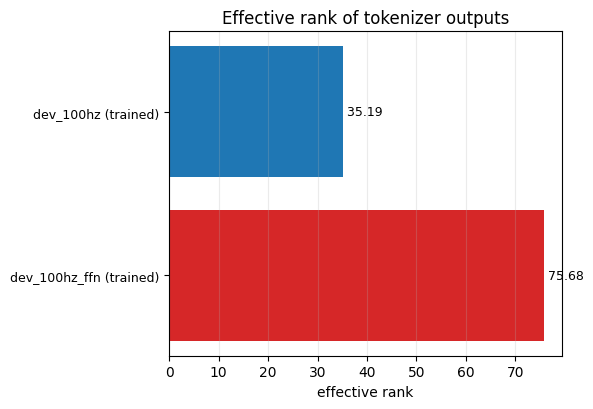

In [11]:
# Just the eRank bar chart (right plot only).
fig, ax_er = plt.subplots(figsize=(6, 4.2))

colors = {
    "dev_100hz (trained)": "#1f77b4",
    "dev_100hz (random init)": "#aec7e8",
    "dev_100hz_ffn (trained)": "#d62728",
    "dev_100hz_ffn (random init)": "#ff9896",
}
names = [lbl for lbl, _s, _e in labels_and_specs]
values = [e for _lbl, _s, e in labels_and_specs]
bar_colors = [colors.get(lbl, "grey") for lbl in names]
ax_er.barh(range(len(names)), values, color=bar_colors)
ax_er.set_yticks(range(len(names)))
ax_er.set_yticklabels(names, fontsize=9)
ax_er.invert_yaxis()
ax_er.set_xlabel("effective rank")
ax_er.set_title("Effective rank of tokenizer outputs")
for i, v in enumerate(values):
    ax_er.text(v, i, f" {v:.2f}", va="center", fontsize=9)
ax_er.grid(True, axis="x", alpha=0.25)

fig.tight_layout()
fig_path = FIG_DIR / "tokenizer_erank_linear_vs_ffn_bar.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print("saved", fig_path)

## Interpretation

- Compare **trained linear** vs. **trained FFN**: if FFN's eRank is meaningfully lower (and its SV curve drops off sooner), the collapse is born at the tokenizer.
- Compare **trained FFN** vs. **random-init FFN**: if the trained FFN is *lower* rank than its own random init, the FFN actively learned to compress patches into a low-dimensional subspace during JEPA pretraining — i.e. the architecture made collapse easy and training found it.
- Compare **trained linear** vs. **random-init linear**: a small rank change here is expected; a single linear layer can't compress more than its initialization geometry allows.

If those three comparisons all point the same way, that's a direct mechanistic story for why the FFN tokenizer caused the AUROC regression.